Проводим статистический анализ корпуса
- построим облако слов для позитивных и негативных
- посчитаем частотность слов
- выделим биграммы

In [ ]:
import pandas as pd # импортируем библиотеку pandas

df = pd.read_csv('../data/chatgpt_reviews_clean_balanced_v2.csv') # загружаем CSV-файл в DataFrame

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              50000 non-null  object
 1   userName              50000 non-null  object
 2   userImage             50000 non-null  object
 3   content               50000 non-null  object
 4   score                 50000 non-null  int64 
 5   thumbsUpCount         50000 non-null  int64 
 6   reviewCreatedVersion  46466 non-null  object
 7   at                    50000 non-null  object
 8   replyContent          1 non-null      object
 9   repliedAt             1 non-null      object
 10  appVersion            46466 non-null  object
 11  content_len_chars     50000 non-null  int64 
 12  language              50000 non-null  object
 13  label                 50000 non-null  object
 14  length                50000 non-null  int64 
 15  tokens                50000 non-null

In [48]:
df['lemmas_str'] = df['lemmas'].apply(
    lambda x: ' '.join(x)
)

In [49]:
negative_text = ' '.join(
    df[df['score'].isin([1, 2])]['lemmas_str']
)

In [50]:
positive_text = ' '.join(
    df[df['score'].isin([4, 5])]['lemmas_str']
)

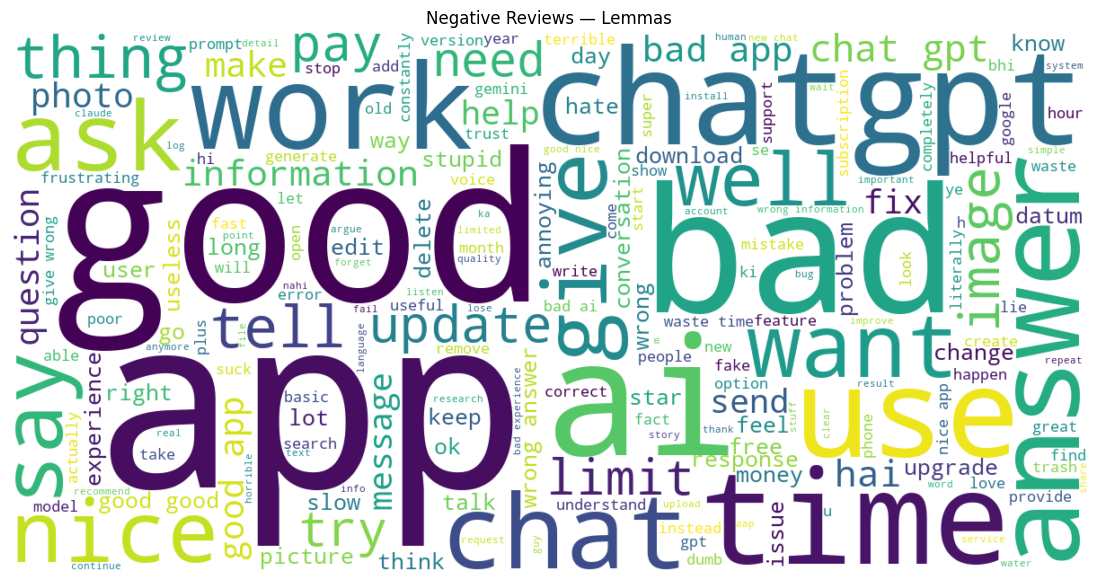

In [51]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wc_negative = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(14,7))

plt.imshow(wc_negative, interpolation='bilinear')

plt.axis('off')

plt.title('Negative Reviews — Lemmas')

plt.show()

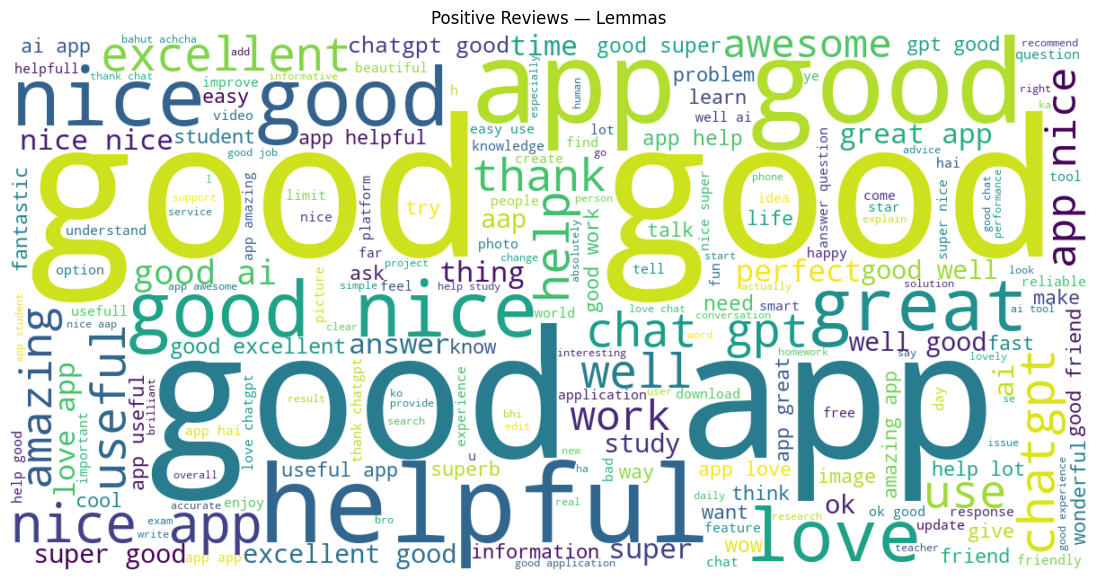

In [52]:
wc_positive = WordCloud(
    width=1200,
    height=600,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(14,7))

plt.imshow(wc_positive, interpolation='bilinear')

plt.axis('off')

plt.title('Positive Reviews — Lemmas')

plt.show()

In [53]:
from collections import Counter

all_words = []

for lemmas in df['lemmas']:
    all_words.extend(lemmas)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('good', 17711),
 ('app', 9785),
 ('nice', 5457),
 ('helpful', 2027),
 ('ai', 2018),
 ('love', 1897),
 ('chatgpt', 1895),
 ('well', 1877),
 ('help', 1876),
 ('like', 1795),
 ('chat', 1708),
 ('great', 1667),
 ('super', 1427),
 ('excellent', 1415),
 ('useful', 1300),
 ('use', 1280),
 ('work', 1235),
 ('gpt', 1115),
 ('answer', 1070),
 ('hai', 1062)]

In [54]:
freq_df = pd.DataFrame(
    word_freq.items(),
    columns=['word', 'frequency']
)

freq_df = freq_df.sort_values(
    by='frequency',
    ascending=False
)

freq_df.head(20)

,word,frequency
18,good,17711
21,app,9785
3,nice,5457
87,helpful,2027
52,ai,2018
66,love,1897
45,chatgpt,1895
64,well,1877
108,help,1876
65,like,1795


In [55]:
# считаем частотность для негативных 1-2

negative_words = []

negative_df = df[df['score'].isin([1, 2])]

for lemmas in negative_df['lemmas']:
    negative_words.extend(lemmas)

negative_freq = Counter(negative_words)

negative_freq.most_common(20)

[('app', 1096),
 ('good', 909),
 ('bad', 565),
 ('ai', 419),
 ('chat', 390),
 ('time', 369),
 ('like', 353),
 ('answer', 349),
 ('chatgpt', 309),
 ('use', 281),
 ('work', 266),
 ('nice', 262),
 ('wrong', 253),
 ('give', 247),
 ('ask', 243),
 ('hai', 234),
 ('image', 214),
 ('well', 188),
 ('information', 185),
 ('say', 180)]